In [1]:
# !pip install xgboost

In [2]:
import joblib
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from google.colab import drive
from scipy.optimize import curve_fit
from xgboost import XGBRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [3]:
df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Features/df_features.parquet')
df = df.rename(columns={'power_cell_mwcm2': 'mpp_mwcm2', 'local_irradiance_mwcm2':'G_mwcm2', 'irradiance_30_degrees_mwcm2':'cams_mwcm2'})
df_3 = df.copy()

In [4]:
def plot_profile(df, cell_id=0, min_gci=0.9, min_G_mwcm2=60, min_power=6.0,
                 isolated_mpp_line=True, start_date=None, end_date=None, color=True,
                 temp=False, feature=None, regression_analysis=False, predicted=False,
                 trend=False, df_window=200, Health=False):

    # 1. Exclusivity validation for the right Y-axis
    active_right_axes = sum([temp, (feature is not None), Health])
    if active_right_axes > 1:
        print('[ERROR] Mutually exclusive usage: "temp", "feature", and "Health" cannot be defined simultaneously on the right axis.')
        return

    # 2. Safe filtering by cell_id
    cell_df = df[df['cell_id'] == cell_id].copy()
    if cell_df.empty:
        print(f"Error: No data found for cell_id {cell_id}.")
        return

    cell_name = 'M0' if cell_id == 0 else 'P12'
    power = 'mpp_mwcm2'
    metric_name = "Pmpp"
    unit = "mW/cm$^2$"

    # 3. Time index preparation
    if 'time' in cell_df.columns:
        cell_df.set_index('time', inplace=True)
    cell_df.index = pd.to_datetime(cell_df.index)
    cell_df.sort_index(inplace=True)

    # 4. Apply Filters
    mask_clear = (cell_df['gci'] > min_gci) & \
                 (cell_df['G_mwcm2'] > min_G_mwcm2) & \
                 (cell_df[power] > min_power)

    cell_df_clear = cell_df[mask_clear].copy()

    # 5. Filter by Dates
    if start_date is not None or end_date is not None:
        if start_date:
            cell_df_clear = cell_df_clear[cell_df_clear.index >= pd.to_datetime(start_date)]
        if end_date:
            cell_df_clear = cell_df_clear[cell_df_clear.index <= pd.to_datetime(end_date)]

    if cell_df_clear.empty:
        print(f"Error: No data meets the filter criteria for cell {cell_id}.")
        return

    # =========================================================================
    # TIME INDEX CALCULATIONS
    # =========================================================================
    if isolated_mpp_line and "isolate_mpp_mwcm2" not in cell_df_clear.columns:
        # Calculate the envelope over real time
        cell_df_clear["isolate_mpp_mwcm2"] = cell_df_clear[power].rolling(window='4min', min_periods=1, center=False).max()

    if trend:
        # Check if either English 'Trend' or Spanish 'Tendencia' is present
        if 'Trend' not in cell_df_clear.columns and 'Tendencia' not in cell_df_clear.columns:
            print("Warning: 'Trend' or 'Tendencia' column not found. Cannot plot trend.")
            trend = False

    if Health and 'Health' not in cell_df_clear.columns:
        print("Warning: 'Health' column not found in dataframe. Cannot plot Health.")
        Health = False

    # =========================================================================
    # PLOT PREPARATION
    # =========================================================================
    days_passed = (cell_df_clear.index - cell_df_clear.index.min()).total_seconds() / (24 * 3600)
    df_plot = cell_df_clear.copy().reset_index()
    idx_x = df_plot.index # X-axis based on row position

    # Temporal Plot
    if temp or (feature is not None) or predicted or trend or Health:
        fig, ax1 = plt.subplots(figsize=(20, 8), dpi=150)

        # Original scatter plot
        if color:
            sc = ax1.scatter(idx_x, df_plot[power], c=days_passed, cmap='coolwarm', alpha=0.5, s=10, label=f'{metric_name} (Raw)')
            cbar = fig.colorbar(sc, ax=ax1, pad=0.1)
            cbar.set_label('Days since start', rotation=270, labelpad=20, fontsize=14)
            cbar.ax.tick_params(labelsize=12)
        else:
            ax1.scatter(idx_x, df_plot[power], alpha=0.5, s=10, label=f'{metric_name} (Raw)')

        ax1.tick_params(axis='y', labelcolor='black', labelsize=12)
        ax1.set_ylabel(f'{metric_name} ({unit})', color='black', fontsize=14)

        # Isolated line
        if isolated_mpp_line:
            label_name = 'Isolated ' + metric_name if "isolate_mpp_mwcm2" in cell_df_clear.columns else 'Calculated Isolated ' + metric_name
            sns.lineplot(x=idx_x, y=df_plot["isolate_mpp_mwcm2"], color='red', linewidth=2, label=label_name, ax=ax1)

        # Predictions
        if predicted and 'mpp_pred_mwcm2' in df_plot.columns:
            if 'is_train' in df_plot.columns:
                train_mask = df_plot['is_train']
                val_mask = ~df_plot['is_train']

                if train_mask.any():
                    sns.lineplot(x=idx_x[train_mask], y=df_plot.loc[train_mask, 'mpp_pred_mwcm2'],
                                 color='green', linewidth=2.5, linestyle='--', label=f'Pred Train {metric_name}', ax=ax1)
                if val_mask.any():
                    sns.lineplot(x=idx_x[val_mask], y=df_plot.loc[val_mask, 'mpp_pred_mwcm2'],
                                 color='darkorange', linewidth=2.5, linestyle='--', label=f'Pred Val {metric_name}', ax=ax1)
            else:
                sns.lineplot(x=idx_x, y=df_plot['mpp_pred_mwcm2'], color='green', linewidth=2.5, linestyle='--', label=f'Predicted {metric_name}', ax=ax1)

        # Irreversible Trend (Left Axis - ax1)
        if trend:
            trend_col = 'Trend' if 'Trend' in df_plot.columns else 'Tendencia'
            sns.lineplot(x=idx_x, y=df_plot[trend_col], color='purple', linewidth=3.5, alpha=0.9, linestyle='-.', label='Irreversible Trend', ax=ax1)

        ax1.legend(loc='upper right', fontsize=14)

        # Secondary Axis (Twinx) only for Temp, extra Features or Health
        if temp or (feature is not None) or Health:
            ax2 = ax1.twinx()
            if temp:
                ax2.tick_params(axis='y', labelcolor='tab:orange', labelsize=12)
                sns.lineplot(x=idx_x, y=df_plot['DeviceTemp'].rolling(window=df_window, min_periods=1, center=False).mean(),
                             color='tab:orange', linewidth=1.5, ax=ax2, alpha=0.7, linestyle=':', label='Temperature Trend')
                ax2.set_ylabel('Device Temp (°C)', color='tab:orange', fontsize=14)

            elif feature is not None:
                if feature in df_plot.columns:
                    ax2.tick_params(axis='y', labelcolor='black', labelsize=12)
                    sns.lineplot(x=idx_x, y=df_plot[feature].rolling(window=df_window, min_periods=1, center=False).mean(),
                                 linewidth=1.5, ax=ax2, alpha=0.7, color='black', linestyle='-.', label=f'{feature} Trend')
                    ax2.set_ylabel(feature, color='black', fontsize=14)

            elif Health:
                ax2.tick_params(axis='y', labelcolor='teal', labelsize=12)
                health_percent = (df_plot['Health'] / df_plot['Health'].max()) * 100

                sns.lineplot(x=idx_x, y=health_percent,
                             linewidth=3, ax=ax2, alpha=0.9, color='teal', linestyle='-', label='Power Retention (Health %)')

                # Mark the critical T80 line
                ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.6, label='T80 Threshold')

                ax2.set_ylabel('Health / Power Retention (%)', color='teal', fontsize=14, fontweight='bold')
                ax2.set_ylim(0, 105) # Fixed upper limit for percentage context

            lines_1, labels_1 = ax1.get_legend_handles_labels()
            lines_2, labels_2 = ax2.get_legend_handles_labels()

            ax2.get_legend().remove() if ax2.get_legend() else None

            # Create the single legend in ax1
            ax1.legend(lines_1 + lines_2, labels_1 + labels_2,
                       loc='upper right', fontsize=12, frameon=True)

        # X-Axis Format
        num_ticks = min(10, len(df_plot))
        tick_indices = np.linspace(0, len(df_plot) - 1, num_ticks, dtype=int)
        tick_labels = df_plot['time'].iloc[tick_indices].dt.strftime('%m-%d %H:%M')

        ax1.set_xticks(tick_indices)
        ax1.set_xticklabels(tick_labels, rotation=45, ha='right')
        ax1.set_xlabel('Time (MM-DD HH:mm)', fontsize=14)
        ax1.set_title(f'Temporal Profile for Cell {cell_name} (ID: {cell_id})', fontsize=16, fontweight='bold')
        ax1.grid(True, alpha=0.3)

    # Hourly Plot (Hourly profile)
    else:
        idx_horario = cell_df_clear.index.hour + cell_df_clear.index.minute/60 + cell_df_clear.index.second/3600
        fig, ax = plt.subplots(figsize=(16, 9))

        if color:
            sc = ax.scatter(idx_horario, cell_df_clear[power], c=days_passed, cmap='coolwarm', alpha=0.5, s=10, label=f'{metric_name}')
            cbar = fig.colorbar(sc, ax=ax)
            cbar.set_label('Days since start', rotation=270, labelpad=20, fontsize=14)
        else:
            ax.scatter(idx_horario, cell_df_clear[power], alpha=0.5, s=10, label=f'{metric_name}')

        if isolated_mpp_line:
            sort_idx = np.argsort(idx_horario)
            sns.lineplot(x=idx_horario[sort_idx], y=cell_df_clear["isolate_mpp_mwcm2"].iloc[sort_idx], color='red', linewidth=2, label=f'Isolated {metric_name}', ax=ax)

        if predicted and 'mpp_pred_mwcm2' in cell_df_clear.columns:
            sort_idx = np.argsort(idx_horario)
            sns.lineplot(x=idx_horario[sort_idx], y=cell_df_clear['mpp_pred_mwcm2'].iloc[sort_idx], color='green', linewidth=2.5, linestyle='--', label=f'Predicted Isolated {metric_name}', ax=ax)

        ax.legend(loc='upper right')
        ax.set_xlabel('Time of day (Solar)', fontsize=14)
        ax.set_ylabel(f'{metric_name} ({unit})', fontsize=14)
        ax.set_title(f'When does cell {cell_name} (ID: {cell_id}) perform well?', fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return

# **Non-Linear Gradient Boosting Architecture with Target Purification**

The **Level 3 Architecture** represents a high-fidelity evolution of the decoupling framework. It moves beyond linear assumptions to capture complex thermodynamic interactions using **Gradient Boosted Trees (XGBoost)**, combined with an algorithmic "purification" of the target signal to isolate the cell's optimal physical state.

---

## **1. Core Mechanisms**

* **Target Purification (Isolation):** Instead of training on raw, noisy data, this architecture segments the signal into temporal windows (e.g., 4 min) and isolates the absolute power peaks (`is_mpp_peak`). This ensures the model learns from the cell's **optimal response**, filtering out MPPT tracking noise and transient fluctuations.
* **Non-Linear Environmental Mapping:** By replacing linear coefficients with an **XGBoost ensemble**, the model captures synergistic effects—such as how the temperature coefficient of perovskite shifts under different irradiance levels—which are invisible to standard linear models.
* **Instantaneous Stationarity:** The architecture deliberately excludes lagged features (e.g., $x_{t-1}$) to prevent **multicollinearity** and **overfitting**. By focusing on the instantaneous state, the model is forced to learn the underlying physics rather than relying on the high auto-correlation of time-series data.
* **Exponential Trend with Plateau:** The degradation is modeled using a three-parameter exponential decay: $$f(t) = a + b \cdot e^{-ct}$$. The parameter $a$ represents the **physical plateau**, distinguishing between the initial "burn-in" and the long-term stable efficiency phase.

---

## **2. Prediction Equation**

The model reconstructs the real-world power output by modulating the non-linear "healthy" prediction with the irreversible health state:

$$P_{mpp}^{pred}(t) = \text{Health}(t) \times f_{XGB}\left( z_G, z_T, z_H, \text{hr}_{sin}, \text{hr}_{cos} \right)$$

**Where:**
* **$\text{Health}(t)$:** The irreversible health factor derived from the plateau-based trend: $$\frac{a + b \cdot e^{-ct}}{\max(\text{Trend})}$$, clipped to $[0.01, 1.0]$.
* **$f_{XGB}(\mathbf{x})$:** The trained XGBoost ensemble function that maps the instantaneous environmental and temporal state to a stationary power value.
* **$z_G, z_T, z_H$:** Standardized environmental inputs (Irradiance, Temperature, Humidity).
* **$\text{hr}_{sin}, \text{hr}_{cos}$:** Trigonometric features capturing the sun's daily trajectory and cyclic periodicities.

---

## **3. Structural Limitations**

> ⚠️ **Scope of the Level 3 Architecture:** This model assumes an **instantaneous non-linear response**. It prioritizes model stability and physical interpretability by avoiding lagged variables that would introduce collinearity. Consequently, it does not account for **thermal inertia** or **ionic migration**, as it treats each observation as an independent physical event without sequential memory.

In [5]:
def make_mi_scores(X, y, discrete_features):
      mi_scores = mutual_info_regression(X, y, discrete_features = discrete_features)
      mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
      mi_scores = mi_scores.sort_values(ascending=False)
      return mi_scores

def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)

    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores (Pmpp Detrended)")
    plt.show()

In [6]:
def level_3(df, cell_id=0, min_G_mwcm2=0, isolate_target=True, window='4min', train_day_split=15, cross_val=False, plot_diagnostics=False, lags=False):
    print(f"Starting Level 3 for cell_id={cell_id}. Modeling Power for MPP_MWCM2...")
    n_splits = 51 - train_day_split

    df = df.copy()

    # Define cell name for plots
    cell_name = 'M0' if cell_id == 0 else 'P12'

    # --- 1. Index Preparation ---
    if 'time' in df.columns:
        df.set_index('time', inplace=True)

    # --- 2. Feature Engineering ---
    df['hour_sin'] = np.sin(2 * np.pi * df['hour_fraction'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour_fraction'] / 24)
    # df['hour_sin_2'] = np.sin(4 * np.pi * df['hour_fraction'] / 24) # 12h
    # df['hour_cos_2'] = np.cos(4 * np.pi * df['hour_fraction'] / 24)

    # df['day_sin'] = np.sin(2 * np.pi * df.index.day / 30)
    # df['day_cos'] = np.cos(2 * np.pi * df.index.day / 30)

    # List of seasonal features for Fourier
    # features_season = [
    #     'hour_sin', 'hour_cos', 'hour_sin_2', 'hour_cos_2',
    #     'day_sin', 'day_cos'
    # ]

    p_vap = 6.112 * np.exp((17.67 * df['AmbientTemp']) / (df['AmbientTemp'] + 243.5)) * (df['Humidity'] / 100.0)
    df['HA_g_m3'] = (216.74 * p_vap) / (df['AmbientTemp'] + 273.15)

    # --- 3. Real MPP Identification ---
    # Group by time blocks to find the real peak of each group
    df['window_group'] = df.index.floor(window)
    idx_mpp = df[df['cell_id'] == cell_id].groupby('window_group')['mpp_mwcm2'].idxmax()
    df['is_mpp_peak'] = False
    df.loc[idx_mpp, 'is_mpp_peak'] = True

    # --- 4. Mask Definition & Train/Validation Split ---
    base_mask = (df['cell_id'] == cell_id) & (df['G_mwcm2'] > min_G_mwcm2) & (df['mpp_mwcm2'].notna())

    if isolate_target:
        train_pool_mask = base_mask & (df['is_mpp_peak'] == True)
    else:
        train_pool_mask = base_mask

    if not train_pool_mask.any():
        print(f"Warning: No valid training data found for cell_id {cell_id}.")
        return df

    start_date = df.loc[train_pool_mask].index.min()
    split_date = start_date + pd.Timedelta(days=train_day_split)

    train_mask = train_pool_mask & (df.index <= split_date)
    valid_mask = train_pool_mask & (df.index > split_date)

    df['is_train'] = df.index <= split_date

    # --- 5. Irreversible Trend Extraction (Exponential Decay with Plateau) ---
    target_1h_df = df.loc[train_pool_mask, 'mpp_mwcm2'].resample('1h').max().dropna()
    target_train_df = target_1h_df[target_1h_df.index <= split_date]

    if len(target_train_df) < 4: # We need at least 4 points for 3 parameters
        print("Error: Not enough 1h data points for exponential trend.")
        return df

    # Time data preparation
    time_zero = df.index.min()
    X_train_hours = (target_train_df.index - time_zero).total_seconds().values / 3600.0
    y_trend_train = target_train_df.values

    # Definition of the physical function: Plateau + Exponential Decay
    def exp_decline(t, a, b, c):
        # a: Plateau (horizontal asymptote)
        # b: Amplitude of the initial decay
        # c: Decay rate
        return a + b * np.exp(-c * t)

    # Smart initial guess to help the algorithm converge
    p0 = [
        y_trend_train.min(),             # a: we assume the plateau is close to the minimum seen
        y_trend_train.max() - y_trend_train.min(), # b: the difference between start and end
        0.001                            # c: a small initial decay rate
    ]

    try:
        # Non-linear fit
        popt, _ = curve_fit(exp_decline, X_train_hours, y_trend_train, p0=p0, maxfev=5000)
        a_opt, b_opt, c_opt = popt

        print(f"\n[INFO] 1. Trend Model: y = {a_opt:.4f} + {b_opt:.4f} * exp(-{c_opt:.6f} * t)")

        # Prediction for all points
        X_all_hours = (df.index - time_zero).total_seconds().values / 3600.0
        trend_raw = exp_decline(X_all_hours, a_opt, b_opt, c_opt)

        # CEILING ADJUSTMENT: So that the purple line passes through the real peaks
        df['Trend'] = trend_raw * (y_trend_train.max() / trend_raw.max())
        df['Trend'] = df['Trend'].clip(lower=a_opt)

    except Exception as e:
        print(f"Warning: Exponential fit failed for cell {cell_id} ({e}). Falling back to Linear.")
        # Optional fallback to linear regression if the exponential fails to converge
        trend_model = LinearRegression().fit(X_train_hours.reshape(-1, 1), y_trend_train)
        df['Trend'] = trend_model.predict((df.index - time_zero).total_seconds().values.reshape(-1, 1) / 3600.0)

    # Detrending (Health normalization)
    # Important: The maximum value is usually the start (t=0)
    trend_max = df['Trend'].max()
    df['Health'] = df['Trend'] / trend_max

    # Safety clip to avoid division by zero, but allowing the plateau
    df['Health'] = np.clip(df['Health'], a_min=0.01, a_max=1.0)
    df['P_mpp_detrended'] = df['mpp_mwcm2'] / df['Health']

    # Lags (Environmental and Physicochemical Inertia)
    # lag_features = []
    # delta_features = [] # We create a separate list for the deltas

    # if lags:
    #     target_features = ['G_mwcm2', 'DeviceTemp', 'HA_g_m3']
    #     n_lags = 1
    #     df['date'] = df.index.date

    #     for feat in target_features:
    #         # 1. Create Lags (Pure memory)
    #         for i in range(1, n_lags + 1):
    #             lag_col_name = f'{feat}_lag_{i}'
    #             df[lag_col_name] = df.groupby(['cell_id', 'date'])[feat].shift(i).bfill()
    #             lag_features.append(lag_col_name)

    #             # 2. Create Deltas (Derivatives/Velocity) using lag_1
    #             if i == 1:
    #                 delta_col_name = f'Delta_{feat}'
    #                 df[delta_col_name] = df[feat] - df[lag_col_name]
    #                 delta_features.append(delta_col_name)

        # df.drop(columns=['date'], inplace=True)
        # print(f"\n[INFO] Calculated lags: {lag_features}")
        # print(f"[INFO] Deltas (Derivatives) integrated into the model: {delta_features}")

    # --- 6. Dynamic Model Fitting ---
    features = ['G_mwcm2', 'DeviceTemp', 'HA_g_m3', 'hour_sin', 'hour_cos']
    X_train = df.loc[train_mask, features]
    y_train_detrended = df.loc[train_mask, 'P_mpp_detrended']
    y_train_detrended = y_train_detrended.clip(upper=df.loc[train_mask, 'mpp_mwcm2'].max() * 1.2)

    # Mutual Information (MI)
    if plot_diagnostics:
        discrete_features = X_train.dtypes == int
        mi_scores = make_mi_scores(X_train, y_train_detrended, discrete_features)
        plt.figure(dpi =100, figsize =(8, 5))
        plot_mi_scores(mi_scores)

    tscv = TimeSeriesSplit(n_splits=5)

    # Millimetric search space (strictly centered on the original values)
    param_dist = {
        'max_depth': [3, 4, 5],                  # Original: 4
        'min_child_weight': [12, 15, 18],        # Original: 15
        'gamma': [0, 0.1],                       # Original: 0 (default)
        'reg_lambda': [45, 50, 55],              # Original: 50
        'reg_alpha': [18, 20, 22],               # Original: 20
        'n_estimators': [950, 1000, 1050],       # Original: 1000
        'learning_rate': [0.008, 0.01, 0.012],   # Original: 0.01
        'subsample': [0.95, 1.0],                # Original: 1.0 (default)
        'colsample_bytree': [0.95, 1.0]          # Original: 1.0 (default)
    }

    xgb_base = XGBRegressor(
        random_state=42,
        n_jobs=-1,
        monotone_constraints="(1, -1, -1, 0, 0)"
    )

    random_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_dist,
        n_iter=50,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        verbose=1,
        random_state=42
    )

    print("\n[INFO] Starting hyperparameter optimization...")
    random_search.fit(X_train, y_train_detrended)
    results = random_search.cv_results_

    print("Best params:", random_search.best_params_)
    print("Best score:", random_search.best_score_)

    dynamic_model = random_search.best_estimator_

    # =====================================================================
    # --- EXTRACTION OF PHYSICAL PARAMETERS (XGBoost SHAP & Hysteresis) ---
    # =====================================================================
    import shap  # Recommended to put it at the beginning of the script along with the other imports

    print(f"\n[PHYSICS EXTRACTION] Cell {cell_id} ({cell_name}) - XGBoost SHAP Analysis")
    try:
        # 1. Calculate SHAP values of the winning model
        explainer = shap.TreeExplainer(dynamic_model)
        shap_values = explainer.shap_values(X_train)

        # 2. Identify the indices of our temporal variables
        idx_sin = features.index('hour_sin')
        idx_cos = features.index('hour_cos')

        # 3. Sum the impact of both components to obtain the total temporal effect
        time_impact_shap = shap_values[:, idx_sin] + shap_values[:, idx_cos]

        # Calculate the amplitude (the "strength" of the temporal memory)
        amplitude_xgb = time_impact_shap.max() - time_impact_shap.min()
        print(f" - Total Temporal Amplitude (SHAP Range): {amplitude_xgb:.4f} mW/cm²")

        if plot_diagnostics:
            # 4. Diurnal Hysteresis Plot
            hour_fraction_train = df.loc[train_mask, 'hour_fraction']

            plt.figure(figsize=(8, 5))
            # Plot the time of day against the impact on power, colored by irradiance
            scatter = plt.scatter(hour_fraction_train, time_impact_shap,
                                  c=X_train['G_mwcm2'], cmap='magma', alpha=0.7, s=15, edgecolors='none')

            plt.colorbar(scatter, label='Irradiance (mW/cm²)')
            plt.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

            plt.xlabel('Time of Day (h)', fontsize=12)
            plt.ylabel('Temporal Impact on Pmpp (SHAP Value)', fontsize=12)
            plt.title(f'Diurnal Hysteresis Learned by XGBoost (Cell {cell_name})\n(Asymmetric impact of hour_sin + hour_cos)')
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f" - Warning: Could not calculate SHAP: {e}")
    print("=====================================================================")

    # Train Metrics Reconstruction (Dynamics + Trend)
    y_train_pred_detrended = dynamic_model.predict(X_train)

#     dynamic_model = XGBRegressor(
#     n_estimators=1000,
#     max_depth=4,
#     learning_rate=0.01,
#     objective='reg:squarederror',
#     tree_method='exact',
#     reg_lambda=50,
#     reg_alpha=20,
#     min_child_weight=15,
#     monotone_constraints="(1, -1, 0, 0, 0)",
#     random_state=42
# )

#     dynamic_model.fit(X_train, y_train_detrended)

    # Train Metrics Reconstruction (Dynamics + Trend)
    y_train_pred_detrended = dynamic_model.predict(X_train)
    y_train_pred_full = y_train_pred_detrended * df.loc[train_mask, 'Health'].values
    y_train_real = df.loc[train_mask, 'mpp_mwcm2']

    mae_t = mean_absolute_error(y_train_real, y_train_pred_full)
    rmse_t = np.sqrt(mean_squared_error(y_train_real, y_train_pred_full))
    r2_t = r2_score(y_train_real, y_train_pred_full)

    print(f'\n[TRAIN] Cell {cell_id} (MPP_MWCM2): MAE: {mae_t:.2f} | RMSE: {rmse_t:.2f} | R2: {r2_t:.4f}')

    # Optimized Train Plot
    plt.figure(figsize=(6,6))

    plt.scatter(y_train_real, y_train_pred_full,
                s=25,
                alpha=0.8,
                color='royalblue',
                edgecolors='w',
                linewidth=0.5,
                label=f'Train Data (Cell {cell_id})')

    # Identity Line (y=x)
    limit_min = min(y_train_real.min(), y_train_pred_full.min())
    limit_max = max(y_train_real.max(), y_train_pred_full.max())
    plt.plot([limit_min, limit_max], [limit_min, limit_max],
             color='red',
             linestyle='--',
             linewidth=2,
             label='Identity Line ($y=x$)')

    # Font adjustments for presentation
    plt.xlabel('Measured MPP ($mW/cm^2$)', fontsize=12)
    plt.ylabel('Predicted MPP ($mW/cm^2$)', fontsize=12)
    plt.title(f'Level 3 - TRAIN (Cell {cell_id})\n$R^2$: {r2_t:.4f}')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- 7. Validation Strategy ---
    X_valid = df.loc[valid_mask, features].bfill()
    y_valid_detrended = df.loc[valid_mask, 'P_mpp_detrended']
    y_valid_real = df.loc[valid_mask, 'mpp_mwcm2']
    valid_health = df.loc[valid_mask, 'Health']

    # 7.1 Global Cross Validation (Walk-Forward over the entire life of the cell)
    if cross_val:
        X_pool = df.loc[train_pool_mask, features]
        y_pool_detrended = df.loc[train_pool_mask, 'P_mpp_detrended']
        y_pool_real = df.loc[train_pool_mask, 'mpp_mwcm2']
        health_pool = df.loc[train_pool_mask, 'Health']

        # Calculate splits based on total days to have ~1 fold per day
        total_days = len(np.unique(X_pool.index.date))
        global_splits = max(2, total_days - 1)

        print(f'\n[VAL] --- Running GLOBAL Time Series Cross-Validation (Splits: {global_splits}) ---')
        tscv = TimeSeriesSplit(n_splits=global_splits)
        cv_mae, cv_rmse, cv_r2 = [], [], []

        for i, (train_idx, test_idx) in enumerate(tscv.split(X_pool), 1):
            X_cv_train = X_pool.iloc[train_idx]
            y_cv_train = y_pool_detrended.iloc[train_idx]

            X_cv_test = X_pool.iloc[test_idx]
            y_cv_test_real = y_pool_real.iloc[test_idx]
            health_cv_test = health_pool.iloc[test_idx]

            # Train the model on this cumulative fold
            dynamic_model.fit(X_cv_train, y_cv_train)

            # Predict and reconstruct
            pred_detrended = dynamic_model.predict(X_cv_test)
            pred_real = pred_detrended * health_cv_test.values

            # Calculate metrics for the current fold
            f_mae = mean_absolute_error(y_cv_test_real, pred_real)
            f_rmse = np.sqrt(mean_squared_error(y_cv_test_real, pred_real))
            f_r2 = r2_score(y_cv_test_real, pred_real)

            cv_mae.append(f_mae)
            cv_rmse.append(f_rmse)
            cv_r2.append(f_r2)

            print(f" - Fold {i:02d}: MAE: {f_mae:.2f} | RMSE: {f_rmse:.2f} | R2: {f_r2:.4f}")

        print(f"\nAverage GLOBAL CV Results -> MAE: {np.mean(cv_mae):.2f} | RMSE: {np.mean(cv_rmse):.2f} | R2: {np.mean(cv_r2):.4f}")
        dynamic_model.fit(X_train, y_train_detrended)

    # 7.2 Daily Block Validation
    if len(X_valid) > 0:
        print(f'\n[VAL] Cell {cell_id}:')
        print(f'--- Evaluating day-to-day temporal performance (Static Model + Trend) ---')

        val_days = np.unique(X_valid.index.date)
        mae_scores, rmse_scores, r2_scores = [], [], []

        for val_date in val_days:
            mask_day = X_valid.index.date == val_date
            X_test_day = X_valid.loc[mask_day]
            y_test_day_real = y_valid_real.loc[mask_day]
            health_day = valid_health.loc[mask_day]

            if len(X_test_day) < 5:
                continue

            # We use the static model trained ONLY with the first X days
            y_pred_day_detrended = dynamic_model.predict(X_test_day)
            y_pred_day_real = y_pred_day_detrended * health_day.values

            m_mae = mean_absolute_error(y_test_day_real, y_pred_day_real)
            m_rmse = np.sqrt(mean_squared_error(y_test_day_real, y_pred_day_real))
            m_r2 = r2_score(y_test_day_real, y_pred_day_real)

            mae_scores.append(m_mae)
            rmse_scores.append(m_rmse)
            r2_scores.append(m_r2)

            print(f"Day {val_date} - MAE: {m_mae:.2f} | RMSE: {m_rmse:.2f} | R2: {m_r2:.4f}")

        if mae_scores:
            print(f"\nTemporal Validation Summary (Daily average):")
            print(f"MAE: {np.mean(mae_scores):.2f} +/- {np.std(mae_scores):.2f}")
            print(f"RMSE: {np.mean(rmse_scores):.2f} | R2: {np.mean(r2_scores):.4f}")

    # --- 8. Final Imputation (Raw Prediction) ---
    pred_mask = (df['cell_id'] == cell_id) & (df['G_mwcm2'] > min_G_mwcm2)

    X_pred_final = df.loc[pred_mask, features].copy()

    final_pred_detrended = dynamic_model.predict(X_pred_final)
    final_pred_full = final_pred_detrended * df.loc[pred_mask,'Health'].values

    if 'mpp_pred_mwcm2' not in df.columns:
        df['mpp_pred_mwcm2'] = np.nan

    df.loc[pred_mask, 'mpp_pred_mwcm2'] = final_pred_full

    # Clean up negative predictions and nighttime data
    df.loc[(df['cell_id'] == cell_id) & (df['G_mwcm2'] <= 0), 'mpp_pred_mwcm2'] = 0
    df.loc[df['cell_id'] == cell_id, 'mpp_pred_mwcm2'] = df.loc[df['cell_id'] == cell_id, 'mpp_pred_mwcm2'].clip(lower=0)

    # Drop temporary calculation variables to keep dataframe clean
    if 'index' in df.columns:
        df = df.drop('index', axis=1)
    df.drop(columns=['window_group', 'is_mpp_peak'], inplace=True, errors='ignore')

    df = df.reset_index().sort_values(by=['cell_id', 'time'])
    print(f"--- Imputation process finished for cell {cell_id} ---")
    return df, dynamic_model, X_train, X_valid

Starting Level 3 for cell_id=0. Modeling Power for MPP_MWCM2...

[INFO] 1. Trend Model: y = 0.2028 + 4.9226 * exp(-0.011614 * t)

[INFO] Starting hyperparameter optimization...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.95, 'reg_lambda': 55, 'reg_alpha': 22, 'n_estimators': 1000, 'min_child_weight': 18, 'max_depth': 5, 'learning_rate': 0.008, 'gamma': 0, 'colsample_bytree': 0.95}
Best score: -0.9437718131265644

[PHYSICS EXTRACTION] Cell 0 (M0) - XGBoost SHAP Analysis
 - Total Temporal Amplitude (SHAP Range): 1.2980 mW/cm²

[TRAIN] Cell 0 (MPP_MWCM2): MAE: 0.15 | RMSE: 0.28 | R2: 0.9643


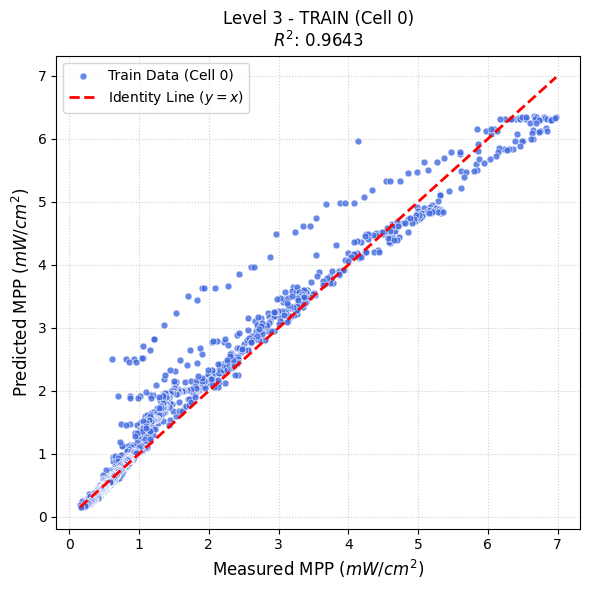


[VAL] --- Running GLOBAL Time Series Cross-Validation (Splits: 50) ---
 - Fold 01: MAE: 0.48 | RMSE: 0.61 | R2: 0.7984
 - Fold 02: MAE: 0.26 | RMSE: 0.30 | R2: 0.8583
 - Fold 03: MAE: 0.14 | RMSE: 0.18 | R2: 0.9225
 - Fold 04: MAE: 0.44 | RMSE: 0.52 | R2: -0.3215
 - Fold 05: MAE: 0.26 | RMSE: 0.30 | R2: -0.9851
 - Fold 06: MAE: 0.07 | RMSE: 0.10 | R2: 0.6571
 - Fold 07: MAE: 0.14 | RMSE: 0.15 | R2: -0.6981
 - Fold 08: MAE: 0.09 | RMSE: 0.10 | R2: 0.3395
 - Fold 09: MAE: 0.05 | RMSE: 0.07 | R2: 0.4814
 - Fold 10: MAE: 0.09 | RMSE: 0.10 | R2: -0.0711
 - Fold 11: MAE: 0.08 | RMSE: 0.08 | R2: 0.0703
 - Fold 12: MAE: 0.07 | RMSE: 0.07 | R2: 0.0947
 - Fold 13: MAE: 0.10 | RMSE: 0.11 | R2: -0.5200
 - Fold 14: MAE: 0.06 | RMSE: 0.06 | R2: -0.2493
 - Fold 15: MAE: 0.06 | RMSE: 0.07 | R2: 0.3297
 - Fold 16: MAE: 0.07 | RMSE: 0.07 | R2: -0.1249
 - Fold 17: MAE: 0.08 | RMSE: 0.09 | R2: -0.5417
 - Fold 18: MAE: 0.06 | RMSE: 0.06 | R2: 0.1706
 - Fold 19: MAE: 0.07 | RMSE: 0.07 | R2: -0.1117
 - Fold

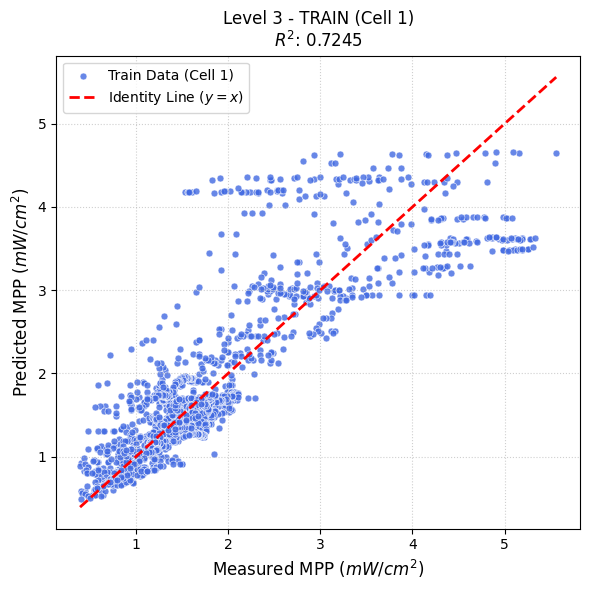


[VAL] --- Running GLOBAL Time Series Cross-Validation (Splits: 50) ---
 - Fold 01: MAE: 1.87 | RMSE: 2.11 | R2: -0.8324
 - Fold 02: MAE: 0.67 | RMSE: 0.77 | R2: 0.5609
 - Fold 03: MAE: 0.42 | RMSE: 0.47 | R2: 0.5408
 - Fold 04: MAE: 0.64 | RMSE: 0.70 | R2: -3.8777
 - Fold 05: MAE: 0.31 | RMSE: 0.36 | R2: 0.1604
 - Fold 06: MAE: 0.24 | RMSE: 0.31 | R2: -4.0073
 - Fold 07: MAE: 0.54 | RMSE: 0.61 | R2: -1.4068
 - Fold 08: MAE: 0.40 | RMSE: 0.47 | R2: -2.9086
 - Fold 09: MAE: 0.49 | RMSE: 0.50 | R2: -0.6000
 - Fold 10: MAE: 0.38 | RMSE: 0.43 | R2: -0.4064
 - Fold 11: MAE: 0.23 | RMSE: 0.28 | R2: -0.0875
 - Fold 12: MAE: 0.14 | RMSE: 0.17 | R2: 0.4375
 - Fold 13: MAE: 0.10 | RMSE: 0.12 | R2: 0.6805
 - Fold 14: MAE: 0.12 | RMSE: 0.15 | R2: 0.7448
 - Fold 15: MAE: 0.20 | RMSE: 0.23 | R2: -0.2074
 - Fold 16: MAE: 0.11 | RMSE: 0.14 | R2: 0.7736
 - Fold 17: MAE: 0.08 | RMSE: 0.11 | R2: 0.6983
 - Fold 18: MAE: 0.16 | RMSE: 0.19 | R2: -0.3967
 - Fold 19: MAE: 0.25 | RMSE: 0.28 | R2: -1.5205
 - Fo

In [7]:
# --- M0 ---
df_res_xg_m0, model_xg_m0, X_train_m0, _ = level_3(df=df_3.copy(), cell_id=0, isolate_target=True,
                    train_day_split=15, cross_val=True)

# --- P12 ---
df_res_xg_p12, model_xg_p12, X_train_p12, _ = level_3(df=df_3.copy(), cell_id=1, isolate_target=True,
                     train_day_split=15, cross_val=True)

M0:


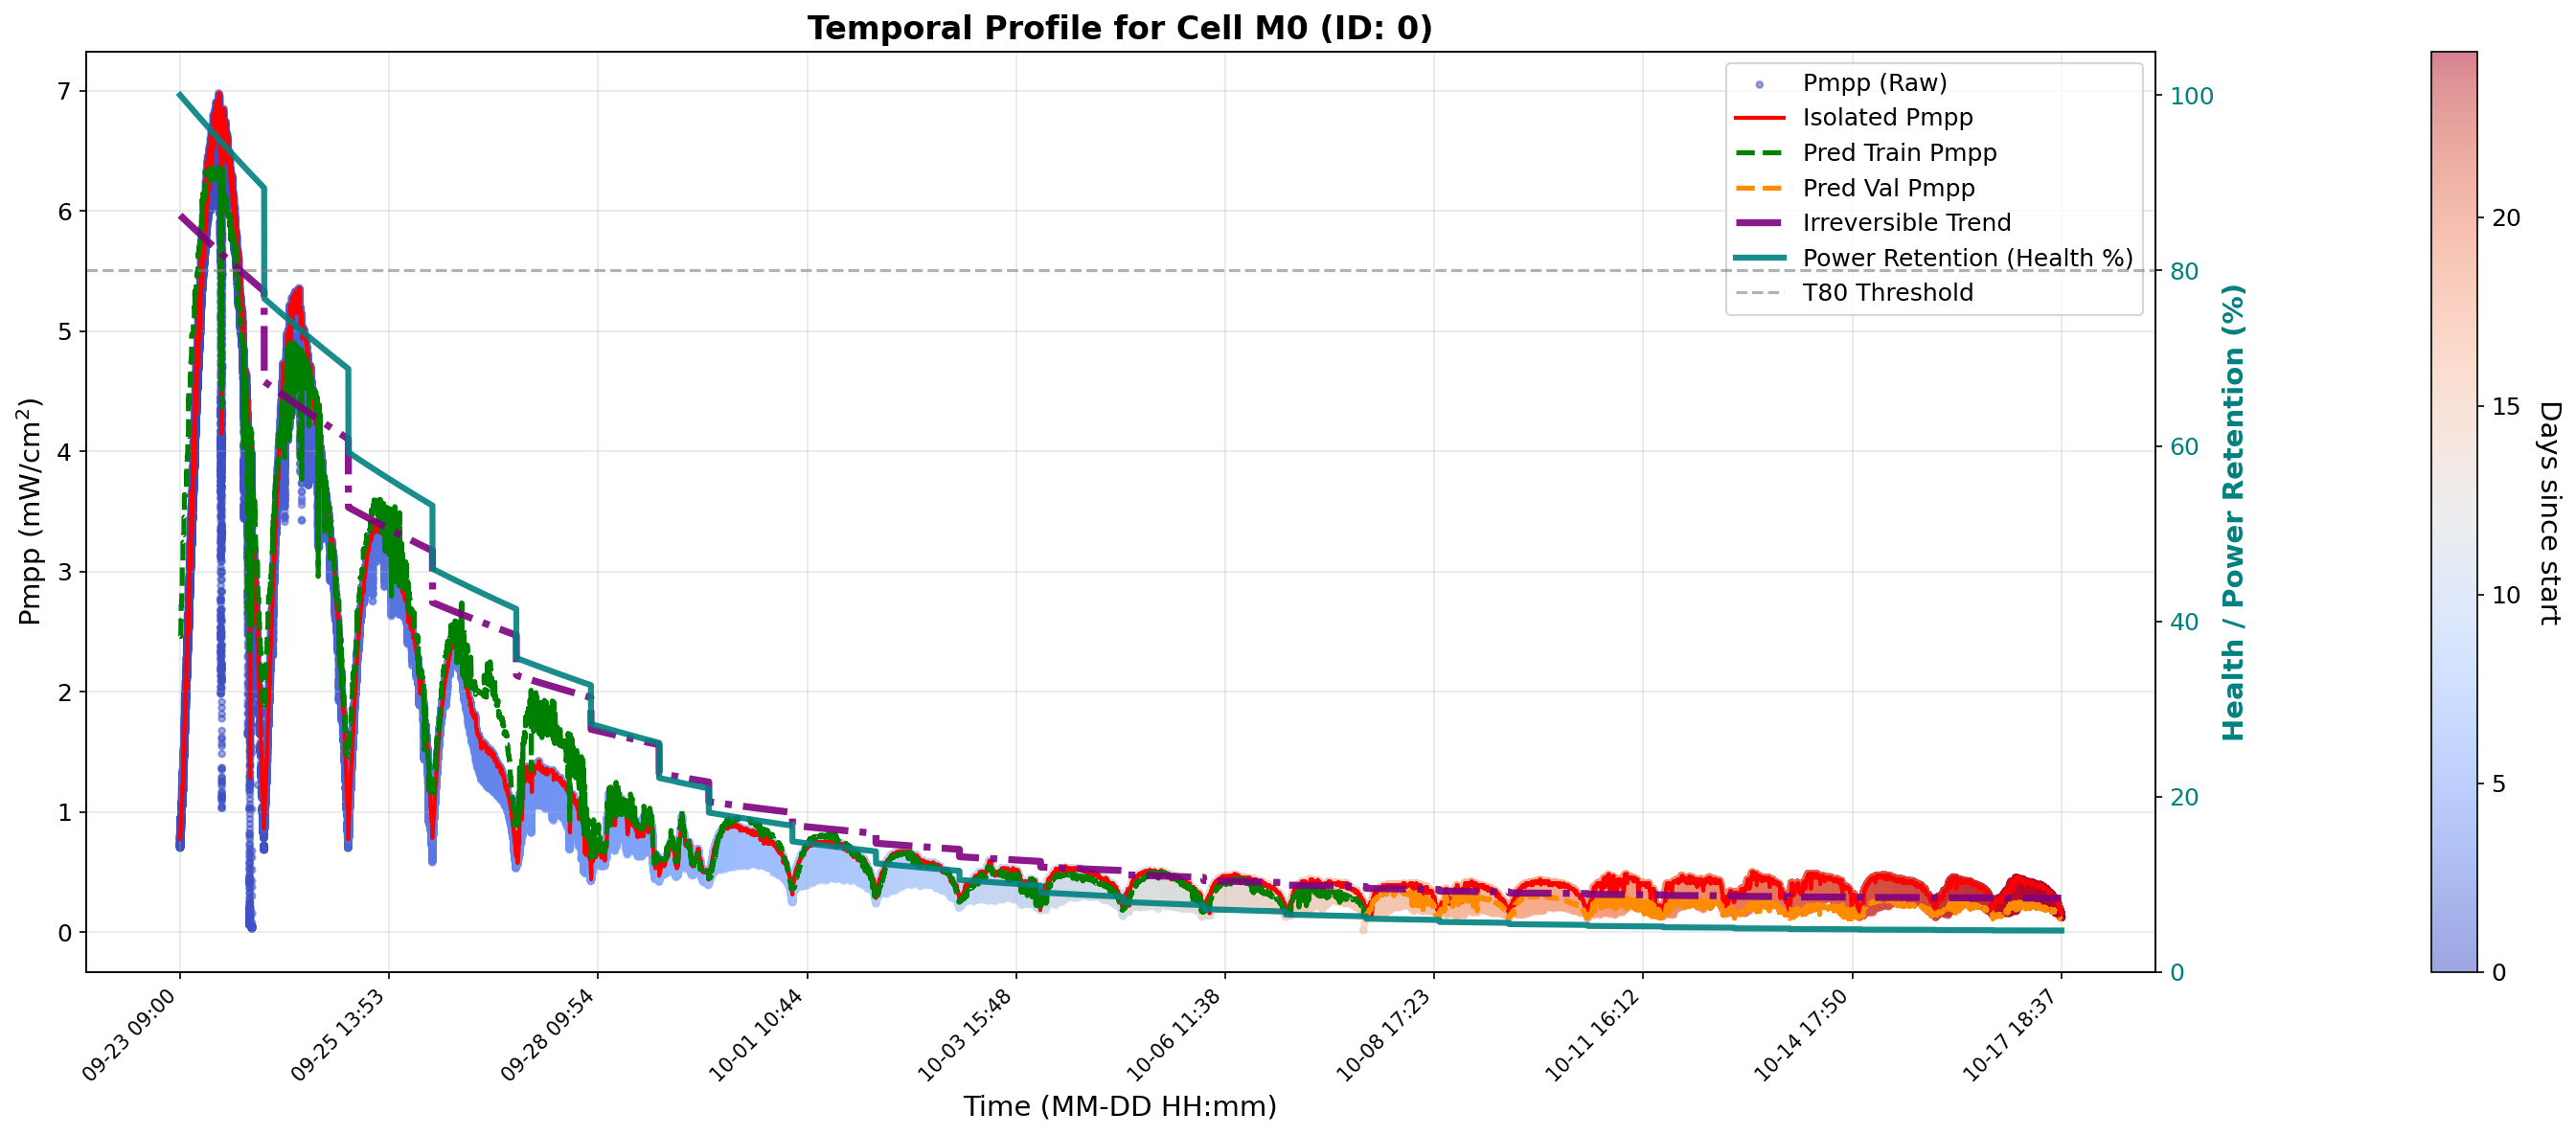


 P12:


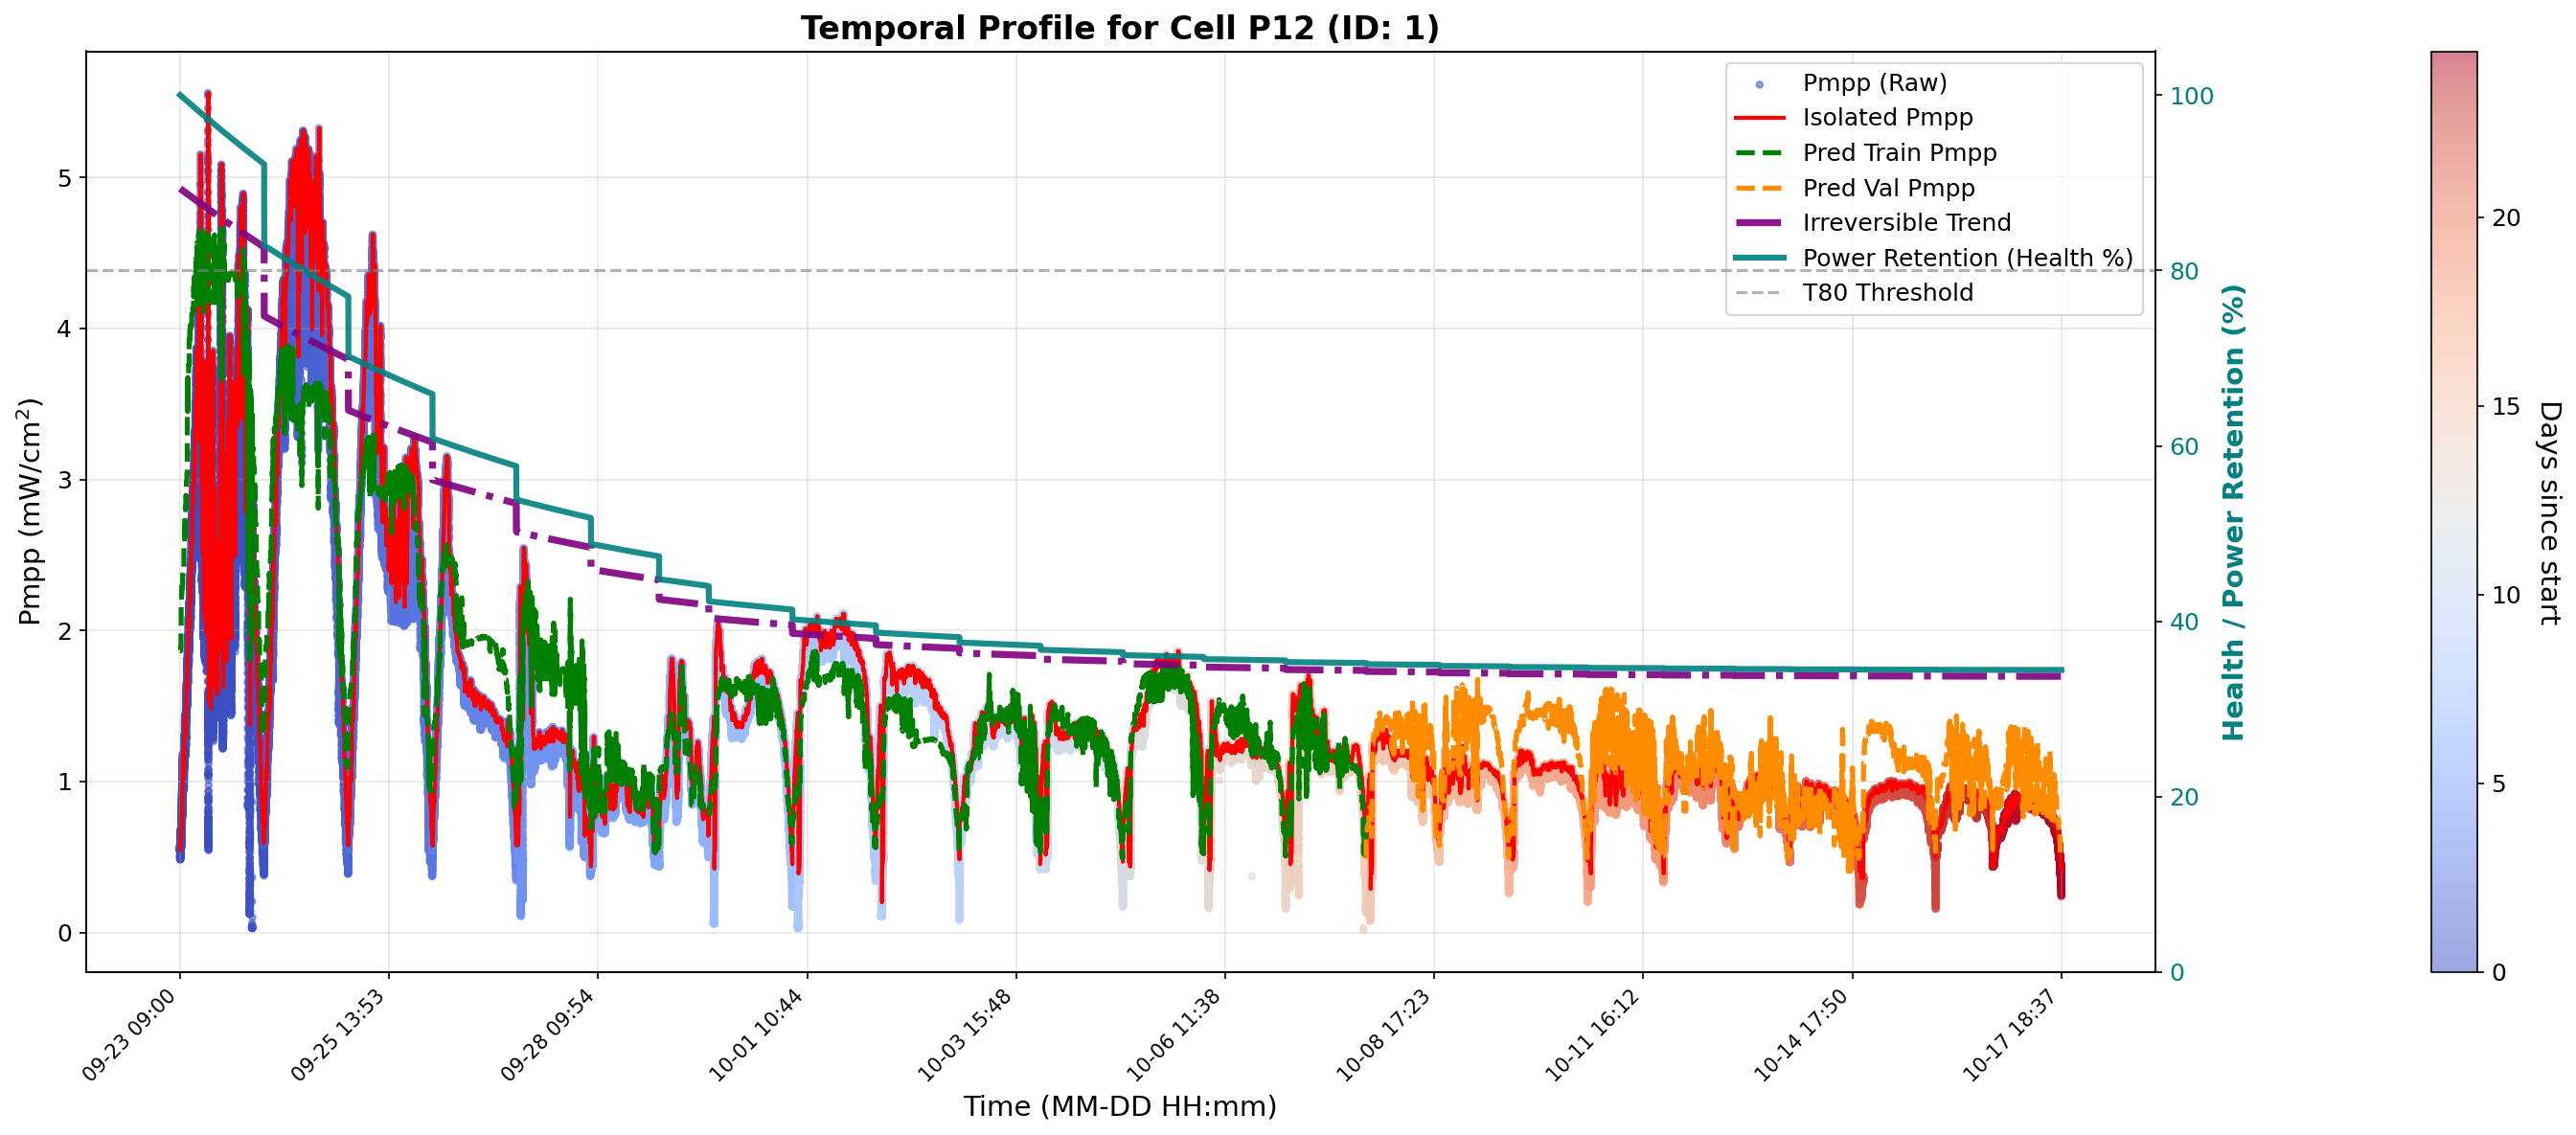

In [8]:
print("M0:")
plot_profile(df=df_res_xg_m0, cell_id=0, min_gci=0, min_G_mwcm2=0, min_power=0, isolated_mpp_line=True,
             start_date=pd.to_datetime('2025-09-23'),
             end_date=pd.to_datetime('2025-09-23') + pd.Timedelta(days=25),
             color=True, temp=False, feature=None, predicted=True, trend=True, Health=True)

print("\n P12:")
plot_profile(df=df_res_xg_p12, cell_id=1, min_gci=0, min_G_mwcm2=0, min_power=0, isolated_mpp_line=True,
             start_date=pd.to_datetime('2025-09-23'),
             end_date=pd.to_datetime('2025-09-23') + pd.Timedelta(days=25),
             color=True, temp=False, feature=None, predicted=True, trend=True, Health=True)

In [9]:
!sudo apt-get update
!sudo apt-get install -y texlive-fonts-recommended texlive-fonts-extra cm-super dvipng

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,956 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,296 kB]
Get:11 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,084 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelea

## **Partial Dependence Plots (PDP)**

*Cyclical temporal variables (hour_sin/cos) are included not as chronological indicators, but as latent state variables that capture time-dependent physical phenomena in perovskites, such as ion migration, hysteresis, and spectral variation throughout the day.*

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


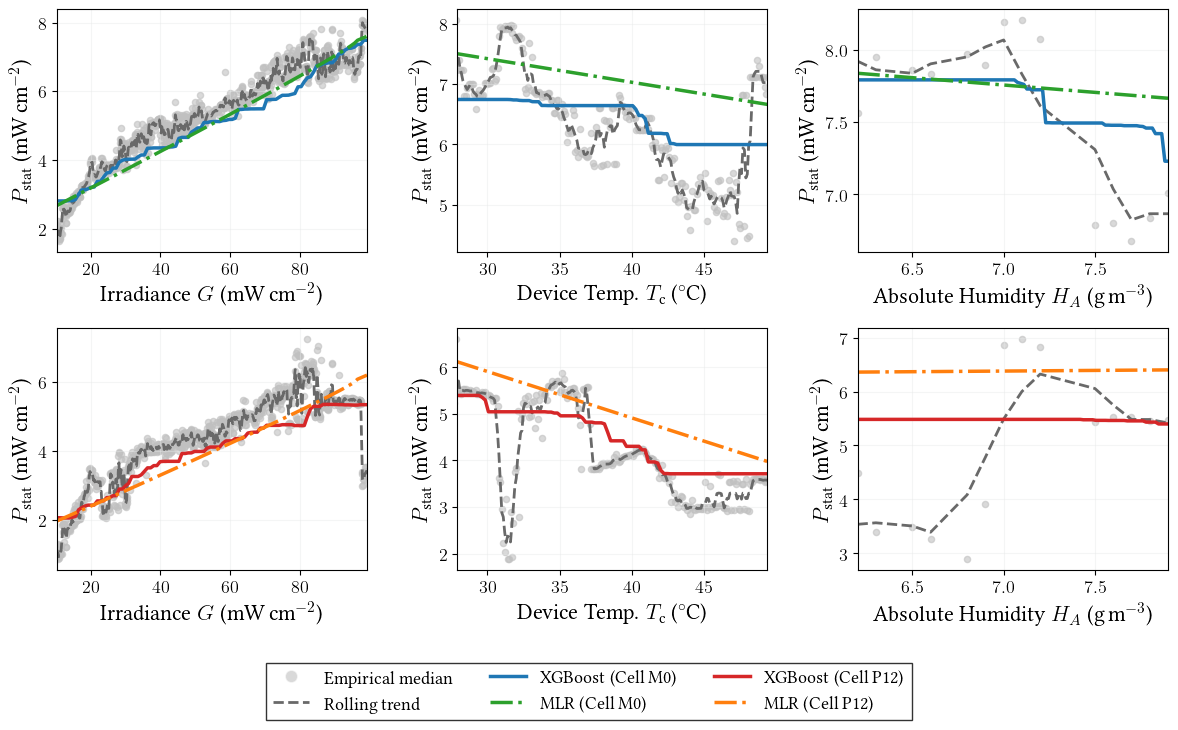

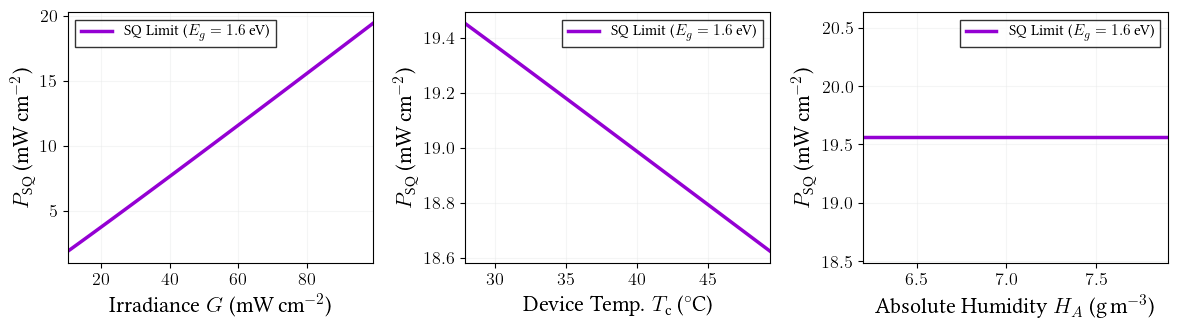

In [10]:
plt.style.use('default')
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'text.latex.preamble': r'\usepackage{libertine} \usepackage[T1]{fontenc} \usepackage{amsmath} \usepackage{bm}',

    # FONT SIZE ADJUSTMENTS
    'font.size': 14,               # General font size
    'axes.labelsize': 16,          # Axis labels (X and Y)
    'xtick.labelsize': 13,         # X-axis tick labels
    'ytick.labelsize': 13,         # Y-axis tick labels
    'legend.fontsize': 13,         # Legend font size
    'axes.titlesize': 16,          # Subplot title size (if used)

    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.color': '#E5E8E8',
    'grid.linestyle': '-',
})

# Dictionary for formal axis names
latex_axis_map = {
    'G_mwcm2': r'Irradiance $G$ (mW\,cm$^{-2}$)',
    'DeviceTemp': r'Device Temp. $T_{\text{c}}$ ($^\circ$C)',
    'HA_g_m3': r'Absolute Humidity $H_A$ (g\,m$^{-3}$)'
}

# ==============================================================================
# PURE THERMODYNAMIC ENGINE (SQ Limit - Jsc corrected for perovskite Eg=1.6eV)
# ==============================================================================
_JSC_TABLE = {
    1.0: 47.0, 1.1: 43.0, 1.2: 37.0, 1.3: 30.0, 1.4: 26.0,
    1.5: 20.5, 1.6: 19.0, 1.7: 15.0, 1.8: 11.0,
}

def _get_jsc_max(E_g_eV):
    """Linear interpolation of the maximum Jsc_SQ (mA/cm²) based on Eg (eV)."""
    egs  = np.array(sorted(_JSC_TABLE.keys()))
    jscs = np.array([_JSC_TABLE[e] for e in egs])
    return float(np.interp(E_g_eV, egs, jscs))

def calculate_SQ_power(G_mwcm2, T_celsius, E_g_eV=1.6):
    """Approximate Shockley-Queisser limit power (mW/cm²)."""
    q   = 1.602e-19
    k_B = 1.3806e-23
    T_K = T_celsius + 273.15
    suns = G_mwcm2 / 100.0
    if suns <= 0:
        return 0.0

    J_sc  = _get_jsc_max(E_g_eV) * suns
    E_g_J = E_g_eV * q
    T_ref   = 300.0
    J_0_ref = 1e-18

    J_0  = J_0_ref * ((T_K / T_ref)**3) * np.exp(
        (E_g_J / (k_B * T_ref)) - (E_g_J / (k_B * T_K))
    )
    V_oc = (k_B * T_K / q) * np.log(1 + (J_sc / (J_0 + 1e-20)))
    v_oc = q * V_oc / (k_B * T_K)
    FF   = (v_oc - np.log(v_oc + 0.72)) / (v_oc + 1) if v_oc > 0 else 0.0

    return J_sc * V_oc * FF


# ==============================================================================
# CELL ISOLATION AND DETRENDING
# ==============================================================================
def prepare_cell_data(df_in, cell_id, train_day_split=15):
    if 'cell_id' in df_in.columns:
        df = df_in[df_in['cell_id'] == cell_id].copy()
    else:
        df = df_in.copy()

    if 'time' in df.columns:
        df['time'] = pd.to_datetime(df['time'])
        df.set_index('time', inplace=True)
    df.sort_index(inplace=True)

    mask_daylight = (df['G_mwcm2'] > 10) & (df['mpp_mwcm2'] > 0)
    unique_days = np.unique(df.loc[mask_daylight].index.date)
    split_date  = unique_days[min(train_day_split, len(unique_days) - 1)]
    train_mask  = mask_daylight & (df.index.date <= split_date)

    if 'P_mpp_detrended' in df.columns:
        df['P_detrended'] = df['P_mpp_detrended']
    else:
        print(f"[ERROR] 'P_mpp_detrended' not found in df for cell {cell_id}.")

    return df[train_mask].dropna(subset=['P_detrended']).copy()


# ==============================================================================
# MAIN VISUALIZATION FUNCTION
# ==============================================================================
def plot_comparison_matrix(df_m0, model_xg_m0, model_lr_m0, X_train_m0,
                           df_p12, model_xg_p12, model_lr_p12, X_train_p12,
                           train_day_split=15, rolling_window=5):

    irradiance_col = 'G_mwcm2'
    df_plot_m0  = prepare_cell_data(df_m0,  cell_id=0, train_day_split=train_day_split)
    df_plot_p12 = prepare_cell_data(df_p12, cell_id=1, train_day_split=train_day_split)

    # Main figure: Empirical vs Models Matrix (2 rows x 3 columns)
    fig_emp, axes_emp = plt.subplots(2, 3, figsize=(12, 7.5))

    # Secondary figure: SQ Limit
    fig_teo, axes_teo = plt.subplots(1, 3, figsize=(12, 3.5))

    features = [irradiance_col, 'DeviceTemp', 'HA_g_m3']

    for i, col in enumerate(features):
        x_min_global, x_max_global = float('inf'), float('-inf')
        x_label = latex_axis_map.get(col, col)

        def process_and_plot(df_plot, X_train, model_xg, model_lr, ax, c_scatter, c_trend, c_xg, c_lr):
            nonlocal x_min_global, x_max_global

            # 1. STRICT STC FILTER
            mask_stc = pd.Series(True, index=df_plot.index)
            if col == irradiance_col:
                mask_stc &= (df_plot['DeviceTemp'] >= 20) & (df_plot['DeviceTemp'] <= 30)
            elif col == 'DeviceTemp':
                mask_stc &= (df_plot[irradiance_col] >= 90) & (df_plot[irradiance_col] <= 110)
            elif col == 'HA_g_m3':
                mask_stc &= (df_plot[irradiance_col] >= 90) & (df_plot[irradiance_col] <= 110)
                mask_stc &= (df_plot['DeviceTemp'] >= 20) & (df_plot['DeviceTemp'] <= 30)

            df_emp = df_plot[mask_stc].copy()

            x_min_exp, x_max_exp = 0.0, 100.0
            if df_emp.empty:
                ax.set_xlabel(x_label)
                ax.set_ylabel(r'$P_{\text{stat}}$ (mW\,cm$^{-2}$)')
                return

            # 2. Empirical median and smoothing
            grouped_emp = df_emp.groupby(df_emp[col].round(1))[['P_detrended']].median().reset_index()
            grouped_emp['Smooth_Emp'] = grouped_emp['P_detrended'].rolling(window=rolling_window, center=True).mean()
            valid_trend = grouped_emp.dropna(subset=['Smooth_Emp'])

            if not valid_trend.empty:
                x_min_exp, x_max_exp = valid_trend[col].min(), valid_trend[col].max()
            else:
                x_min_exp, x_max_exp = X_train[col].min(), X_train[col].max()

            x_min_global = min(x_min_global, x_min_exp)
            x_max_global = max(x_max_global, x_max_exp)

            # 3. Synthetic input for ML
            columnas_modelo = X_train.columns
            contexto_stc    = df_emp[columnas_modelo].median()
            G_vals          = np.linspace(x_min_exp, x_max_exp, 100)

            synthetic_X      = pd.DataFrame([contexto_stc] * 100).reset_index(drop=True)
            synthetic_X[col] = G_vals

            # Set STC explicitly
            if irradiance_col in synthetic_X.columns and col != irradiance_col:
                synthetic_X[irradiance_col] = 100.0
            if 'DeviceTemp' in synthetic_X.columns and col != 'DeviceTemp':
                synthetic_X['DeviceTemp'] = 25.0

            # Couple the solar trajectory
            if col == irradiance_col and 'hour_sin' in synthetic_X.columns:
                G_max_ref  = df_emp[irradiance_col].quantile(0.99)
                ratio      = np.clip(G_vals / max(G_max_ref, 1.0), 0.0, 1.0)
                hour_solar = 12.0 - (12.0 / np.pi) * np.arccos(ratio)
                synthetic_X['hour_sin'] = np.sin(2 * np.pi * hour_solar / 24)
                synthetic_X['hour_cos'] = np.cos(2 * np.pi * hour_solar / 24)
            elif 'hour_sin' in synthetic_X.columns:
                synthetic_X['hour_sin'] = df_emp['hour_sin'].median()
                synthetic_X['hour_cos'] = df_emp['hour_cos'].median()

            # ML Predictions
            ml_pred_xg = model_xg.predict(synthetic_X)
            ml_pred_lr = model_lr.predict(synthetic_X)

            # Scatter and lines (WITHOUT INDIVIDUAL LEGEND)
            ax.scatter(grouped_emp[col], grouped_emp['P_detrended'],
                       color=c_scatter, alpha=0.6, s=20)
            ax.plot(grouped_emp[col], grouped_emp['Smooth_Emp'],
                    color=c_trend, lw=2, ls='--')

            ax.plot(synthetic_X[col], ml_pred_xg, color=c_xg, lw=2.5)
            ax.plot(synthetic_X[col], ml_pred_lr, color=c_lr, lw=2.5, ls='-.')

            # Clean axes
            ax.set_xlabel(x_label)
            ax.set_ylabel(r'$P_{\text{stat}}$ (mW\,cm$^{-2}$)')

        # Row 0: M0
        process_and_plot(df_plot_m0, X_train_m0, model_xg_m0, model_lr_m0, axes_emp[0, i],
                         'silver', 'dimgray', 'tab:blue', 'tab:green')
        # Row 1: P12
        process_and_plot(df_plot_p12, X_train_p12, model_xg_p12, model_lr_p12, axes_emp[1, i],
                         'silver', 'dimgray', 'tab:red', 'tab:orange')

        # Synchronize X axes
        if x_min_global != float('inf') and x_max_global != float('-inf'):
            axes_emp[0, i].set_xlim(x_min_global, x_max_global)
            axes_emp[1, i].set_xlim(x_min_global, x_max_global)

        # ------------------------------------------------------------------
        # FIGURE 2: Pure theoretical SQ curve
        # ------------------------------------------------------------------
        x_teo = np.linspace(x_min_global, x_max_global, 100) if x_min_global != float('inf') else np.linspace(0, 100, 100)
        df_teo = pd.DataFrame({col: x_teo})

        df_teo[irradiance_col] = x_teo if col == irradiance_col else 100.0
        df_teo['DeviceTemp']    = x_teo if col == 'DeviceTemp'    else 25.0

        teorica_pura = [calculate_SQ_power(row[irradiance_col], row['DeviceTemp']) for _, row in df_teo.iterrows()]

        axes_teo[i].plot(df_teo[col], teorica_pura, color='darkviolet', lw=2.5, label=r'SQ Limit ($E_g=1.6$ eV)')
        axes_teo[i].set_xlabel(x_label)
        axes_teo[i].set_ylabel(r'$P_{\text{SQ}}$ (mW\,cm$^{-2}$)')
        axes_teo[i].legend(loc='best', fontsize=11, frameon=True, fancybox=False, edgecolor='black')
        axes_teo[i].set_xlim(x_min_global, x_max_global)

    # ==============================================================================
    # CUSTOM LOWER GLOBAL LEGEND
    # ==============================================================================
    legend_elements = [
        mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='silver', markersize=9, alpha=0.6, label=r'Empirical median'),
        mlines.Line2D([0], [0], color='dimgray', lw=2, ls='--', label=r'Rolling trend'),
        mlines.Line2D([0], [0], color='tab:blue', lw=2.5, label=r'XGBoost (Cell M0)'),
        mlines.Line2D([0], [0], color='tab:green', lw=2.5, ls='-.', label=r'MLR (Cell M0)'),
        mlines.Line2D([0], [0], color='tab:red', lw=2.5, label=r'XGBoost (Cell P12)'),
        mlines.Line2D([0], [0], color='tab:orange', lw=2.5, ls='-.', label=r'MLR (Cell P12)')
    ]

    # 1. Change the 'y' value from -0.05 to 0.02 to raise the legend
    fig_emp.legend(handles=legend_elements, loc='lower center',
                   bbox_to_anchor=(0.5, 0.01), ncol=3, fontsize=13,
                   frameon=True, fancybox=False, edgecolor='black')

    # Increase the lower margin (from 0.08 to 0.12) to fit the larger legend
    fig_emp.tight_layout(rect=[0, 0.12, 1, 1])
    fig_emp.savefig("comparison_matrix.pdf", bbox_inches='tight', dpi=600)

    fig_teo.tight_layout()
    fig_teo.savefig("sq_limit.pdf", bbox_inches='tight', dpi=600)

    plt.show()

# ==============================================================================
# EXECUTION
# ==============================================================================
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Modeling/Resultados_LR/'

df_res_m0_lr = pd.read_parquet(save_path + 'df_res_m0_lr.parquet')
X_train_m0_lr    = pd.read_parquet(save_path + 'X_train_m0.parquet')
model_lr_m0  = joblib.load(save_path + 'model_lr_m0.pkl')

df_res_p12_lr = pd.read_parquet(save_path + 'df_res_p12_lr.parquet')
X_train_p12_lr    = pd.read_parquet(save_path + 'X_train_p12.parquet')
model_lr_p12  = joblib.load(save_path + 'model_lr_p12.pkl')

plot_comparison_matrix(
    df_m0=df_res_xg_m0,   model_xg_m0=model_xg_m0,   model_lr_m0=model_lr_m0,   X_train_m0=X_train_m0,
    df_p12=df_res_xg_p12, model_xg_p12=model_xg_p12, model_lr_p12=model_lr_p12, X_train_p12=X_train_p12,
)

# **SHAP Values (SHapley Additive exPlanations)**

In [17]:
# !pip install --upgrade shap


--- NUMERICAL AND PHYSICAL SHAP ANALYSIS: CELL M0 (XGBoost) ---
Base Value (Mean Prediction): 5.3415 mW/cm²

Global Feature Importance (Mean |SHAP|):
   Feature  Global_Importance (|SHAP|)
   G_mwcm2                      0.8551
  hour_cos                      0.2714
   HA_g_m3                      0.2478
DeviceTemp                      0.1315
  hour_sin                      0.0760
------------------------------------------------------------


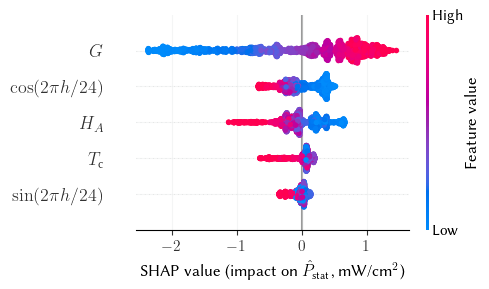


--- NUMERICAL AND PHYSICAL SHAP ANALYSIS: CELL P12 (XGBoost) ---
Base Value (Mean Prediction): 3.8630 mW/cm²

Global Feature Importance (Mean |SHAP|):
   Feature  Global_Importance (|SHAP|)
   G_mwcm2                      0.6272
DeviceTemp                      0.3484
  hour_cos                      0.1283
   HA_g_m3                      0.1275
  hour_sin                      0.0811
------------------------------------------------------------


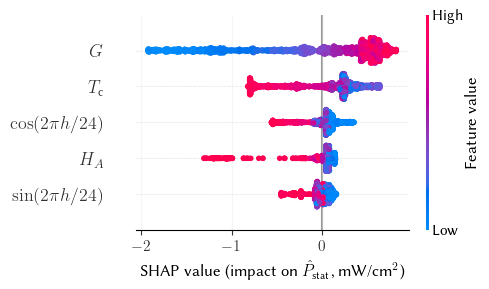


[PHYSICS EXTRACTION - XGBoost] Cell 0 (M0)
 - Temporal Amplitude (SHAP Range): 1.2980 mW/cm² (MLR limited to ~0.95)
 - Time of Maximum Fatigue: 19.12 h
 - Inertia / Empirical Phase Shift: ~7.12 hours after noon (MLR forced ~7.31h)
---------------------------------------------------------------------


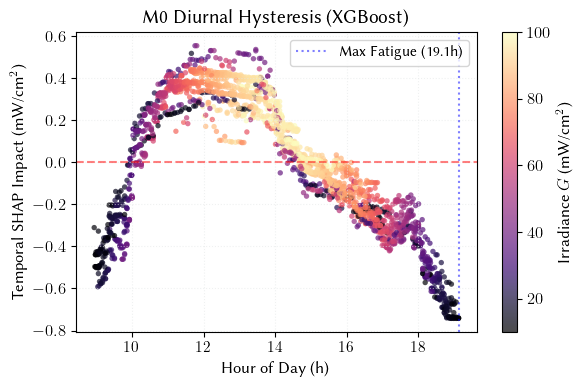


[PHYSICS EXTRACTION - XGBoost] Cell 1 (P12)
 - Temporal Amplitude (SHAP Range): 0.9711 mW/cm² (MLR limited to ~0.33)
 - Time of Maximum Fatigue: 18.94 h
 - Inertia / Empirical Phase Shift: ~6.94 hours after noon (MLR forced ~11.80h)



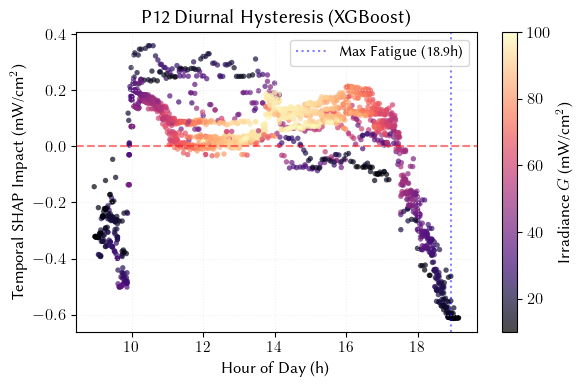

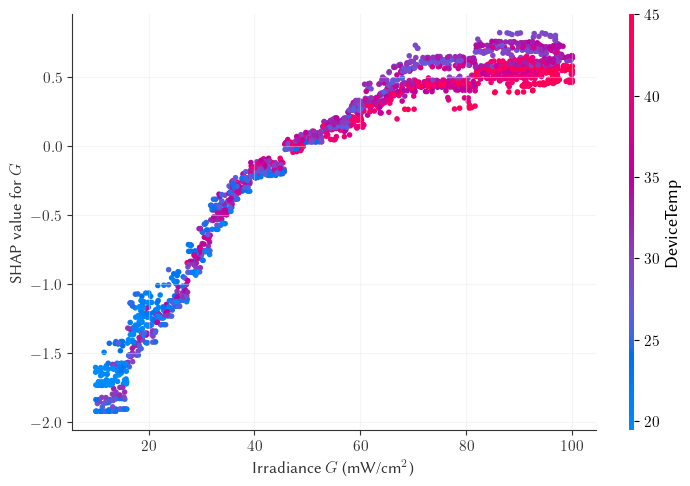

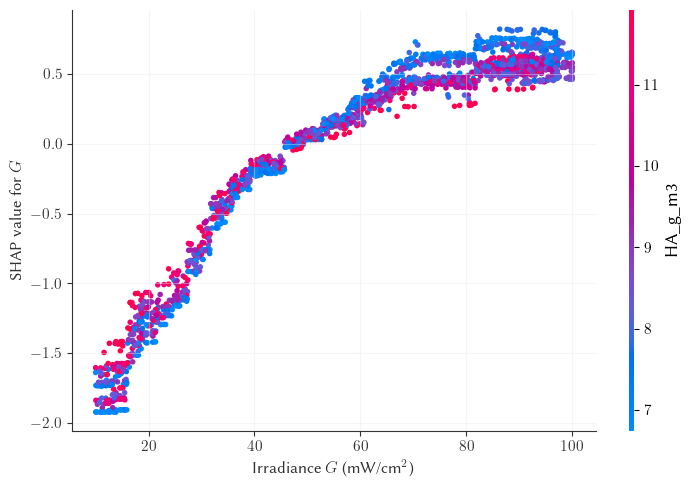

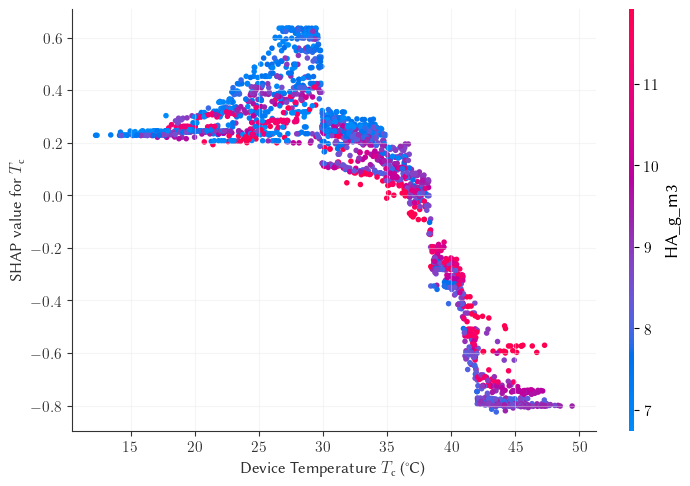

In [19]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,          # General base size
    'axes.labelsize': 12,     # Axis title size (xlabel/ylabel)
    'xtick.labelsize': 11,    # X-axis tick number size
    'ytick.labelsize': 12,    # Y-axis feature name size
    'axes.titlesize': 14,     # Plot title size
    'legend.fontsize': 11,    # Legend font size
    'figure.autolayout': True # Prevents text from being cut off at the edges
})

# 1. Dictionary with the EXACT names of your features
latex_labels_map = {
    'G_mwcm2': r'$G$',
    'DeviceTemp': r'$T_{\text{c}}$',
    'HA_g_m3': r'$H_A$',
    'hour_sin': r'$\sin(2\pi h/24)$',
    'hour_cos': r'$\cos(2\pi h/24)$'
}

# ==========================================
# FOR M0 CELL (XGBoost)
# ==========================================
print("\n" + "="*60)
print("--- NUMERICAL AND PHYSICAL SHAP ANALYSIS: CELL M0 (XGBoost) ---")
print("="*60)

explainer_m0 = shap.TreeExplainer(model_xg_m0)
shap_values_m0 = explainer_m0.shap_values(X_train_m0)

# Apply mapping to LaTeX names
feature_names_m0_latex = [latex_labels_map.get(col, col) for col in X_train_m0.columns]
feature_names_raw = X_train_m0.columns

# --- 1. Numerical Information ---
base_value_m0 = explainer_m0.expected_value
if isinstance(base_value_m0, np.ndarray): base_value_m0 = base_value_m0[0]
print(f"Base Value (Mean Prediction): {base_value_m0:.4f} mW/cm²\n")

mean_abs_shap_m0 = np.abs(shap_values_m0).mean(axis=0)

df_shap_m0 = pd.DataFrame({
    'Feature': feature_names_raw,
    'Global_Importance (|SHAP|)': mean_abs_shap_m0
}).sort_values(by='Global_Importance (|SHAP|)', ascending=False)

print("Global Feature Importance (Mean |SHAP|):")
print(df_shap_m0.to_string(index=False, float_format="%.4f"))
print("-" * 60)

# --- 2. Summary Plot ---
shap.summary_plot(shap_values_m0, X_train_m0, feature_names=feature_names_m0_latex, plot_size=(5, 3), show=False)
plt.xlabel(r'SHAP value (impact on $\hat{P}_{\text{stat}}$, mW/cm$^2$)', fontsize=12)
plt.savefig("shap_xg_m0.pdf", bbox_inches='tight', dpi=600)
plt.show()
plt.close()


# ==========================================
# FOR P12 CELL (XGBoost)
# ==========================================
print("\n" + "="*60)
print("--- NUMERICAL AND PHYSICAL SHAP ANALYSIS: CELL P12 (XGBoost) ---")
print("="*60)

explainer_p12 = shap.TreeExplainer(model_xg_p12)
shap_values_p12 = explainer_p12.shap_values(X_train_p12)

# Apply mapping to LaTeX names
feature_names_p12_latex = [latex_labels_map.get(col, col) for col in X_train_p12.columns]

# --- 1. Numerical Information ---
base_value_p12 = explainer_p12.expected_value
if isinstance(base_value_p12, np.ndarray): base_value_p12 = base_value_p12[0]
print(f"Base Value (Mean Prediction): {base_value_p12:.4f} mW/cm²\n")

mean_abs_shap_p12 = np.abs(shap_values_p12).mean(axis=0)

df_shap_p12 = pd.DataFrame({
    'Feature': feature_names_raw,
    'Global_Importance (|SHAP|)': mean_abs_shap_p12
}).sort_values(by='Global_Importance (|SHAP|)', ascending=False)

print("Global Feature Importance (Mean |SHAP|):")
print(df_shap_p12.to_string(index=False, float_format="%.4f"))
print("-" * 60)

# --- 2. Summary Plot ---
shap.summary_plot(shap_values_p12, X_train_p12, feature_names=feature_names_p12_latex, plot_size=(5, 3), show=False)
plt.xlabel(r'SHAP value (impact on $\hat{P}_{\text{stat}}$, mW/cm$^2$)', fontsize=12)
plt.savefig("shap_xg_p12.pdf", bbox_inches='tight', dpi=600)
plt.show()
plt.close()


# =====================================================================
# --- PHYSICS EXTRACTION: DIURNAL HYSTERESIS (Both cells) ---
# =====================================================================
idx_sin = list(X_train_m0.columns).index('hour_sin')
idx_cos = list(X_train_m0.columns).index('hour_cos')

# ---------------------------------------------------------------------
# --- M0 Cell ---
# ---------------------------------------------------------------------
time_impact_m0 = shap_values_m0[:, idx_sin] + shap_values_m0[:, idx_cos]
amplitude_m0 = time_impact_m0.max() - time_impact_m0.min()

hour_fraction_m0 = (np.arctan2(X_train_m0['hour_sin'], X_train_m0['hour_cos']) * 24 / (2 * np.pi)) % 24
min_idx_m0 = np.argmin(time_impact_m0)
hour_max_fatigue_m0 = hour_fraction_m0.iloc[min_idx_m0] if hasattr(hour_fraction_m0, 'iloc') else hour_fraction_m0[min_idx_m0]
desfase_m0_horas = hour_max_fatigue_m0 - 12.0

print("\n[PHYSICS EXTRACTION - XGBoost] Cell 0 (M0)")
print(f" - Temporal Amplitude (SHAP Range): {amplitude_m0:.4f} mW/cm² (MLR limited to ~0.95)")
print(f" - Time of Maximum Fatigue: {hour_max_fatigue_m0:.2f} h")
print(f" - Inertia / Empirical Phase Shift: ~{desfase_m0_horas:.2f} hours after noon (MLR forced ~7.31h)")
print("---------------------------------------------------------------------")

plt.figure(figsize=(6, 4))
scatter_m0 = plt.scatter(hour_fraction_m0, time_impact_m0,
                         c=X_train_m0['G_mwcm2'], cmap='magma', alpha=0.7, s=15, edgecolors='none')
cbar_m0 = plt.colorbar(scatter_m0)
cbar_m0.set_label(r'Irradiance $G$ (mW/cm$^2$)', size=12) # Force size in colorbar

plt.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
plt.axvline(hour_max_fatigue_m0, color='blue', linestyle=':', alpha=0.5, label=f'Max Fatigue ({hour_max_fatigue_m0:.1f}h)')

plt.xlabel('Hour of Day (h)', fontsize=12)
plt.ylabel(r'Temporal SHAP Impact (mW/cm$^2$)', fontsize=12)
plt.title('M0 Diurnal Hysteresis (XGBoost)', fontsize=14)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("shap_hysteresis_m0.pdf", bbox_inches='tight', dpi=600)
plt.show()
plt.close()

# ---------------------------------------------------------------------
# --- P12 Cell ---
# ---------------------------------------------------------------------
time_impact_p12 = shap_values_p12[:, idx_sin] + shap_values_p12[:, idx_cos]
amplitude_p12 = time_impact_p12.max() - time_impact_p12.min()

hour_fraction_p12 = (np.arctan2(X_train_p12['hour_sin'], X_train_p12['hour_cos']) * 24 / (2 * np.pi)) % 24
min_idx_p12 = np.argmin(time_impact_p12)
hour_max_fatigue_p12 = hour_fraction_p12.iloc[min_idx_p12] if hasattr(hour_fraction_p12, 'iloc') else hour_fraction_p12[min_idx_p12]
desfase_p12_horas = hour_max_fatigue_p12 - 12.0

print("\n[PHYSICS EXTRACTION - XGBoost] Cell 1 (P12)")
print(f" - Temporal Amplitude (SHAP Range): {amplitude_p12:.4f} mW/cm² (MLR limited to ~0.33)")
print(f" - Time of Maximum Fatigue: {hour_max_fatigue_p12:.2f} h")
print(f" - Inertia / Empirical Phase Shift: ~{desfase_p12_horas:.2f} hours after noon (MLR forced ~11.80h)")
print("=====================================================================\n")

plt.figure(figsize=(6, 4))
scatter_p12 = plt.scatter(hour_fraction_p12, time_impact_p12,
                          c=X_train_p12['G_mwcm2'], cmap='magma', alpha=0.7, s=15, edgecolors='none')
cbar_p12 = plt.colorbar(scatter_p12)
cbar_p12.set_label(r'Irradiance $G$ (mW/cm$^2$)', size=12) # Force size in colorbar

plt.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
plt.axvline(hour_max_fatigue_p12, color='blue', linestyle=':', alpha=0.5, label=f'Max Fatigue ({hour_max_fatigue_p12:.1f}h)')

plt.xlabel('Hour of Day (h)', fontsize=12)
plt.ylabel(r'Temporal SHAP Impact (mW/cm$^2$)', fontsize=12)
plt.title('P12 Diurnal Hysteresis (XGBoost)', fontsize=14)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("shap_hysteresis_p12.pdf", bbox_inches='tight', dpi=600)
plt.show()
plt.close()

# ==========================================
# DEPENDENCE AND INTERACTION PLOTS (P12)
# ==========================================
# SHAP sometimes resets axes internally, we can force by updating the current figure (gca)
shap.dependence_plot("G_mwcm2", shap_values_p12, X_train_p12, interaction_index="DeviceTemp", show=False)
plt.gca().set_xlabel(r'Irradiance $G$ (mW/cm$^2$)', fontsize=12)
plt.gca().set_ylabel(r'SHAP value for $G$', fontsize=12)
plt.savefig("shap_dep_G_Temp_p12.pdf", bbox_inches='tight', dpi=600)
plt.show()
plt.close()

shap.dependence_plot("G_mwcm2", shap_values_p12, X_train_p12, interaction_index="HA_g_m3", show=False)
plt.gca().set_xlabel(r'Irradiance $G$ (mW/cm$^2$)', fontsize=12)
plt.gca().set_ylabel(r'SHAP value for $G$', fontsize=12)
plt.savefig("shap_dep_G_HA_p12.pdf", bbox_inches='tight', dpi=600)
plt.show()
plt.close()

shap.dependence_plot("DeviceTemp", shap_values_p12, X_train_p12, interaction_index="HA_g_m3", show=False)
plt.gca().set_xlabel(r'Device Temperature $T_{\text{c}}$ (°C)', fontsize=12)
plt.gca().set_ylabel(r'SHAP value for $T_{\text{c}}$', fontsize=12)
plt.savefig("shap_dep_Temp_HA_p12.pdf", bbox_inches='tight', dpi=600)
plt.show()
plt.close()